# Feature Engineering

In [51]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("orders.db")
df = pd.read_sql("SELECT * FROM orders", conn)

df.head()

,order_id,product_id,user_id,order_date,return_date,product_category,product_price,order_quantity,return_reason,return_status,days_to_return,user_age,user_gender,user_location,payment_method,shipping_method,discount_applied
0,ORD00000000,PROD00000000,USER00000000,2023-08-05,2024-08-26,Clothing,411.59,3,Changed mind,Returned,387.0,58,Male,City54,Debit Card,Next-Day,45.27
1,ORD00000001,PROD00000001,USER00000001,2023-10-09,2023-11-09,Books,288.88,3,Wrong item,Returned,31.0,68,Female,City85,Credit Card,Express,47.79
2,ORD00000002,PROD00000002,USER00000002,2023-05-06,None,Toys,390.03,5,None,Not Returned,NaN,22,Female,City30,Debit Card,Next-Day,26.64
3,ORD00000003,PROD00000003,USER00000003,2024-08-29,None,Toys,401.09,3,None,Not Returned,NaN,40,Male,City95,PayPal,Next-Day,15.37
4,ORD00000004,PROD00000004,USER00000004,2023-01-16,None,Books,110.09,4,None,Not Returned,NaN,34,Female,City80,Gift Card,Standard,16.37


In [52]:
# convert dataset into numberic form
df["return_flag"] = df["return_status"].map({"Returned":1, "Not Returned":0})
df["return_flag"].value_counts()

return_flag
1    5052
0    4948
Name: count, dtype: int64

In [53]:
# drop useless columns 
df = df.drop(columns=[
"order_id",
"product_id",
"user_id",
"return_status",
"return_date"
])

,order_date,product_category,product_price,order_quantity,return_reason,days_to_return,user_age,user_gender,user_location,payment_method,shipping_method,discount_applied,return_flag
0,2023-08-05,Clothing,411.59,3,Changed mind,387.0,58,Male,City54,Debit Card,Next-Day,45.27,1
1,2023-10-09,Books,288.88,3,Wrong item,31.0,68,Female,City85,Credit Card,Express,47.79,1
2,2023-05-06,Toys,390.03,5,None,NaN,22,Female,City30,Debit Card,Next-Day,26.64,0
3,2024-08-29,Toys,401.09,3,None,NaN,40,Male,City95,PayPal,Next-Day,15.37,0
4,2023-01-16,Books,110.09,4,None,NaN,34,Female,City80,Gift Card,Standard,16.37,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2023-10-20,Home,142.50,4,None,NaN,37,Male,City40,PayPal,Standard,34.27,0
9996,2023-02-25,Electronics,484.63,3,None,NaN,69,Male,City62,Debit Card,Express,25.44,0
9997,2024-05-10,Toys,386.57,5,None,NaN,46,Male,City74,Credit Card,Next-Day,12.67,0
9998,2024-02-13,Toys,129.22,1,None,NaN,34,Female,City34,Gift Card,Express,49.97,0


In [54]:
# extract day, manths, year, week from date
df["order_date"] = pd.to_datetime(df["order_date"])

df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["order_weekday"] = df["order_date"].dt.weekday
df["order_year"] = df["order_date"].dt.year

In [55]:
# group by product price
df["price_range"] = pd.cut(
    df["product_price"],
    bins=[0,200,400,600,1000],
    labels=["Low","Medium","High","Premium"]
)

In [56]:
# group by user age 
df["age_group"] = pd.cut(
    df["user_age"],
    bins=[18,25,35,50,80],
    labels=["18-25","26-35","36-50","50+"]
)

In [57]:
# filter out most popular cities
top_cities = df["user_location"].value_counts().head(10).index
df["city_group"] = df["user_location"].apply(
    lambda x: x if x in top_cities else "Other"
)
df = df.drop(columns=["user_location"])

In [58]:
# Encode Categorical Variables
df = pd.get_dummies(df, drop_first=True)

In [59]:
# list of columns we have
list(df.columns)

['order_date',
 'product_price',
 'order_quantity',
 'days_to_return',
 'user_age',
 'discount_applied',
 'return_flag',
 'order_month',
 'order_day',
 'order_weekday',
 'order_year',
 'product_category_Clothing',
 'product_category_Electronics',
 'product_category_Home',
 'product_category_Toys',
 'return_reason_Defective',
 'return_reason_Not as described',
 'return_reason_Wrong item',
 'user_gender_Male',
 'payment_method_Debit Card',
 'payment_method_Gift Card',
 'payment_method_PayPal',
 'shipping_method_Next-Day',
 'shipping_method_Standard',
 'price_range_Medium',
 'price_range_High',
 'price_range_Premium',
 'age_group_26-35',
 'age_group_36-50',
 'age_group_50+',
 'city_group_City22',
 'city_group_City26',
 'city_group_City28',
 'city_group_City3',
 'city_group_City36',
 'city_group_City43',
 'city_group_City81',
 'city_group_City85',
 'city_group_City86',
 'city_group_Other']

In [60]:
df.shape

(10000, 40)

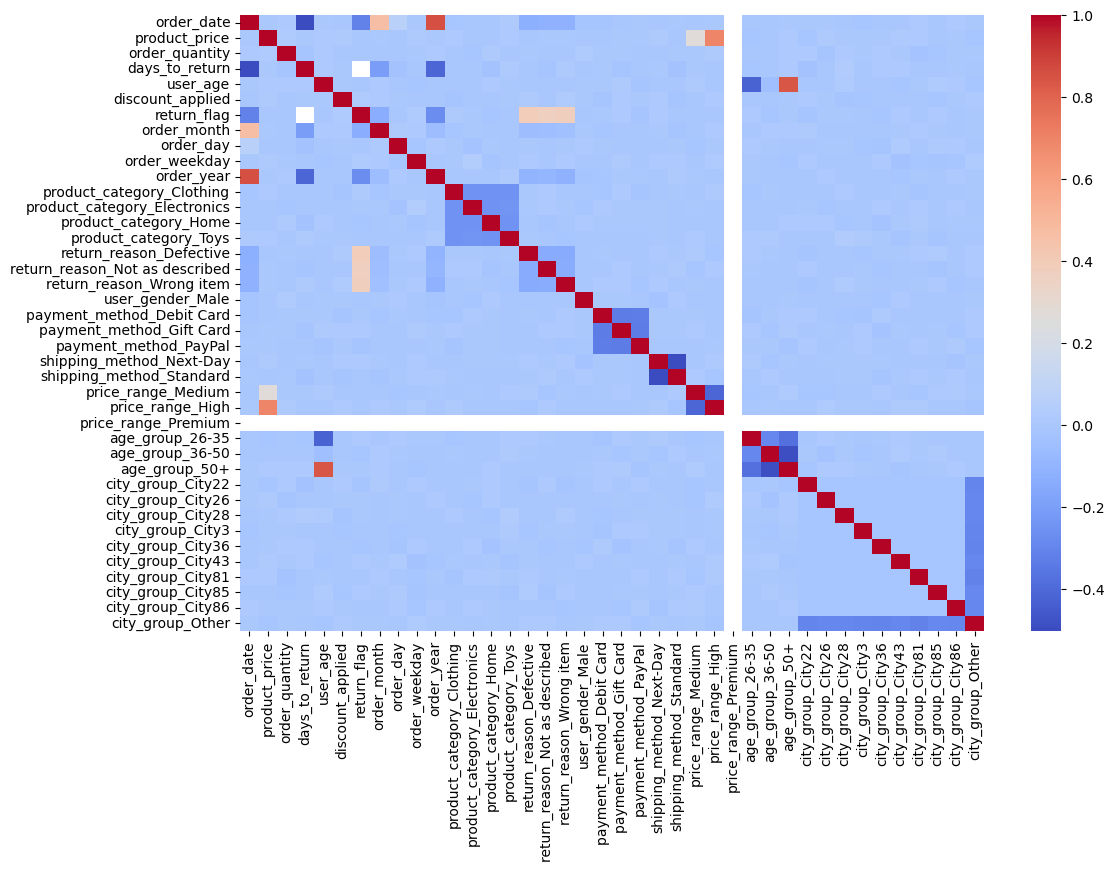

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()